In [1]:
import pandas as pd

# Loading the datasets 
df_23 = pd.read_csv('data/Dataminers_2023.tsv', sep='\t')
df_24 = pd.read_json('data/Dataminers_2024.json')
df_25 = pd.read_xml('data/Dataminers_2025.xml')

In [2]:
# Cleaning column names and removing special characters
def clean_columns(df):
    df.columns = (
        df.columns
        .str.replace('_', ' ', regex=False)   # Replace underscores with spaces
        .str.replace('(', ' ', regex=False)   # Replace '(' with space
        .str.replace(')', ' ', regex=False)   # Replace ')' with space
        .str.replace('?', ' ', regex=False)   # Replace ')' with space
        .str.replace('"', '', regex=False)   # Replace ')' with space
        .str.replace(r'\s+', ' ', regex=True)  # Replace multiple spaces with single space
        .str.strip()                          # Remove leading/trailing spaces
    )
    return df

# Clean the datasets
df_23 = clean_columns(df_23)
df_24 = clean_columns(df_24)
df_25 = clean_columns(df_25)

In [3]:
# Save cleaned datasets
df_23.to_csv('data/cleaned_df_23.csv', index=False)
df_24.to_csv('data/cleaned_df_24.csv', index=False)
df_25.to_csv('data/cleaned_df_25.csv', index=False)

In [4]:
# Dataminers_2023 dataset
df_23 = pd.read_csv('data/cleaned_df_23.csv')
df_23['Year'] = 2023 # adding 'year' column for each dataset
df_23['Enter Your Password'] = '#DAMIN&2023#'


# Dataminers_2024 dataset
df_24 = pd.read_csv('data/cleaned_df_24.csv')
df_24['Year'] = 2024

# Dataminers_2025 dataset
df_25 = pd.read_csv('data/cleaned_df_25.csv')
df_25['Year'] = 2025

In [5]:
# Display shapes of cleaned datasets
print("DF23 shape:", df_23.shape)
print("DF24 shape:", df_24.shape)
print("DF25 shape:", df_25.shape)

DF23 shape: (90, 8)
DF24 shape: (38, 8)
DF25 shape: (50, 8)


In [6]:
# Common column naming convention
rename_map = {
    'Your mean shoe size In European Continental system': 'Your mean shoe size In the European Continental system',
    'Your mean shoe size In the European Continental system': 'Your mean shoe size In the European Continental system',
    'Your mean shoe size In the European Continental system': 'Your mean shoe size In the European Continental system',

    'Which programme are you studying': 'Which program are you studying',
    'Which program are you studying': 'Which program are you studying',
    'Which program are you studying': 'Which program are you studying',

}

# Renaming columns for consistency
df_23.rename(columns=rename_map, inplace=True)
df_24.rename(columns=rename_map, inplace=True)
df_25.rename(columns=rename_map, inplace=True)

In [7]:
# Check if there is any difference in columns names between datasets
set(df_24.columns) ^ set(df_25.columns)

set()

In [8]:
# Combine datasets
combined_df = pd.concat([df_23, df_24, df_25], ignore_index=True)
# Save combined dataset
combined_df.to_csv('data/combined_dataset.csv', index=False)

In [9]:
combined_df.shape

(178, 8)

In [10]:
# Define the target column name
seattle_col = "How many letters are there in the word Seattle"

# Normalize case and convert values
combined_df[seattle_col] = combined_df[seattle_col].astype(str).str.strip().str.upper().map(lambda x: 1 if x == "7" or x == "SEVEN" else 0)

# Check the result
print(combined_df[seattle_col].value_counts())

# Display first few rows of the combined dataset
display(combined_df.head())


How many letters are there in the word Seattle
1    109
0     69
Name: count, dtype: int64


,Timestamp,Your mean shoe size In the European Continental system,Which program are you studying,Your height in International inches,Why are you taking this course,How many letters are there in the word Seattle,Year,Enter Your Password
0,26/08/2020 08:32:49,44.0,"MSc Software Design, ITU",75.59,It'll give me business skills,0,2023,#DAMIN&2023#
1,26/08/2020 08:33:16,38.0,"MSc Software Design, ITU",167.0,"It is the most exciting, This was mandatory fo...",0,2023,#DAMIN&2023#
2,26/08/2020 08:33:22,44.0,"MSc Software Design, ITU",192.0,This was mandatory for me,0,2023,#DAMIN&2023#
3,26/08/2020 08:33:24,38.0,"MSc Software Design, ITU",66.0,"It is the most exciting, It'll give me busines...",0,2023,#DAMIN&2023#
4,26/08/2020 08:33:25,44.0,"MSc Software Design, ITU",184.0,It'll give me business skills,0,2023,#DAMIN&2023#


In [18]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy="mean")
combined_df["Your height in International inches"] = mean_imputer.fit_transform(
    combined_df[["Your height in International inches"]]
)

In [19]:
# Define columns
height_col = "Your height in International inches"

# Ensure numeric values (coerce errors to NaN)
combined_df[height_col] = pd.to_numeric(combined_df[height_col], errors='coerce')

# Convert any value over 85 to 220 (cm) into inches
combined_df.loc[(combined_df[height_col] > 85) & (combined_df[height_col] <= 220), height_col] = combined_df[height_col] / 2.54

# Optional: round to one decimal place
combined_df[height_col] = combined_df[height_col].round(1)

combined_df.to_csv("data/combined_dataset_fixed.csv", index=False)

In [22]:
import matplotlib as mpl

mpl.use("pgf")  # use PGF backend

# Update matplotlib parameters for LaTeX compatibility
mpl.rcParams.update({
    "pgf.rcfonts": False,
    "text.usetex": True,          # LaTeX for all text
    "font.family": "serif",       # match your LaTeX doc
    "font.size": 18,              # will scale nicely in LaTeX
})

#### 1. What is the relation between shoe size and height?

In [23]:
import matplotlib.pyplot as plt
import numpy as np

combined_df = pd.read_csv("data/combined_dataset_fixed.csv")

# Define columns
height_col = "Your height in International inches"
shoe_col = "Your mean shoe size In the European Continental system"

# Convert to numeric just in case
combined_df[height_col] = pd.to_numeric(combined_df[height_col], errors='coerce')
combined_df[shoe_col] = pd.to_numeric(combined_df[shoe_col], errors='coerce')

# Remove outliers
filtered_combined_df = combined_df[
    (combined_df[height_col].between(48, 85)) & 
    (combined_df[shoe_col].between(25, 48))
].copy()

print(f"After removing outliers remaining data points: {len(filtered_combined_df)}")

# Calculate correlation
corr = filtered_combined_df[height_col].corr(filtered_combined_df[shoe_col])
print(f"\nCorrelation between height and shoe size: {corr:.2f}")

# Visualize relationship
plt.figure(figsize=(8,6))
plt.scatter(filtered_combined_df[shoe_col], filtered_combined_df[height_col], alpha=0.6)
plt.title("Relationship Between Shoe Size and Height")
plt.xlabel("Shoe Size (EU)")
plt.ylabel("Height (inches)")

# Adding trendline
m, b = np.polyfit(filtered_combined_df[shoe_col], filtered_combined_df[height_col], 1)
plt.plot(filtered_combined_df[shoe_col], m*filtered_combined_df[shoe_col] + b, color='red', label='Trendline')
plt.legend()
plt.grid(True)
plt.savefig("./figures/shoe_size_vs_height.pgf")
plt.tight_layout()
plt.show()

After removing outliers remaining data points: 166

Correlation between height and shoe size: 0.78


RuntimeError: 'pdflatex' not found; install it or change rcParams['pgf.texsystem'] to an available TeX implementation

#### Applying linear regression using library

After removing outliers remaining data points: 149

Linear Regression Results:
Equation: Height = 24.37 + 1.09 × ShoeSize
R² (Coefficient of Determination): 0.686


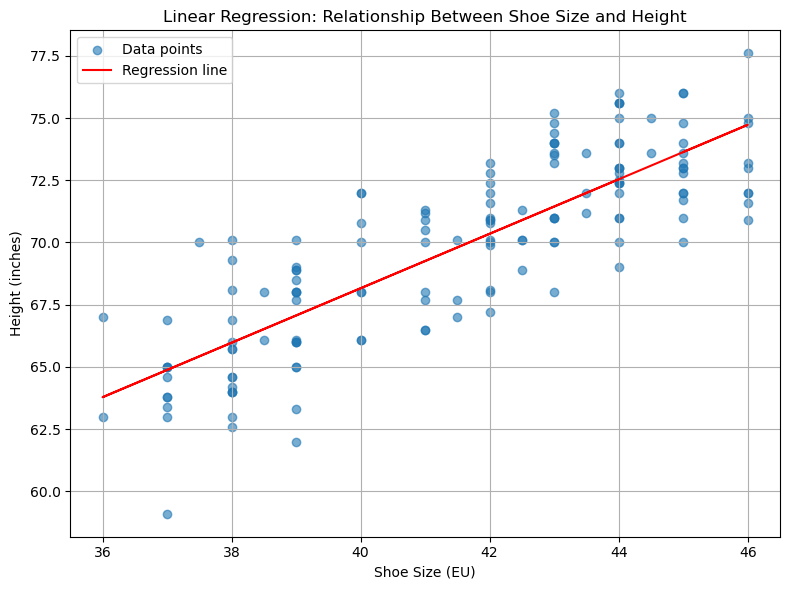

In [54]:
from sklearn.linear_model import LinearRegression


# Defining columns
height_col = "Your height in International inches"
shoe_col = "Your mean shoe size In the European Continental system"

# Converting to numeric just in case
combined_df[height_col] = pd.to_numeric(combined_df[height_col], errors='coerce')
combined_df[shoe_col] = pd.to_numeric(combined_df[shoe_col], errors='coerce')

# Removing outliers
filtered_df = combined_df[
    (combined_df[height_col].between(48, 85)) &
    (combined_df[shoe_col].between(25, 48))
].copy()

print(f"After removing outliers remaining data points: {len(filtered_df)}")

# Preparing data for regression
X = filtered_df[[shoe_col]]  # Independent variable
y = filtered_df[height_col]  # Dependent variable

# Fitting Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Getting model parameters
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(X, y)

print("\nLinear Regression Results:")
print(f"Equation: Height = {intercept:.2f} + {slope:.2f} × ShoeSize")
print(f"R² (Coefficient of Determination): {r2:.3f}")

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X, y, alpha=0.6, label='Data points')
plt.plot(X, model.predict(X), color='red', label='Regression line')

plt.title("Linear Regression: Relationship Between Shoe Size and Height")
plt.xlabel("Shoe Size (EU)")
plt.ylabel("Height (inches)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/figures/shoe_size_vs_height_linear_regression.pgf")
plt.show()


#### 2. What are the reasons for attending this course in each study program?

Possible motivation column: ['Why are you taking this course']

Analyzing motivation column: Why are you taking this course



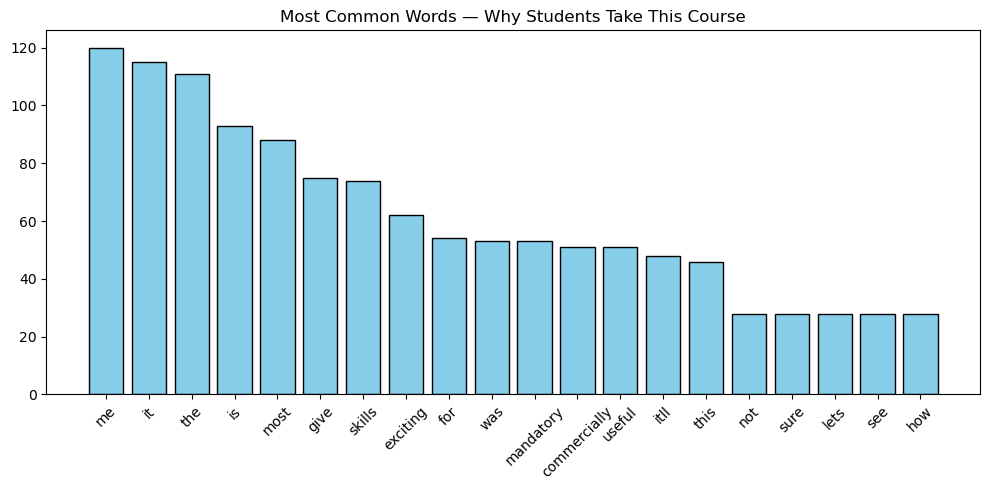

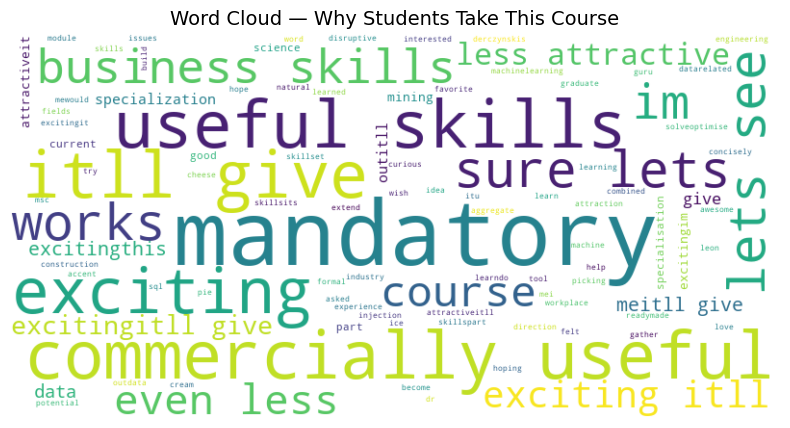

In [55]:
from wordcloud import WordCloud
from collections import Counter
import re

# Try to find a motivation column
motivation_col = [col for col in combined_df.columns if 'why' in col.lower() or 'course' in col.lower()]
print("Possible motivation column:", motivation_col)

# Assuming the column is:
col = motivation_col[0]  # pick the right one
print(f"\nAnalyzing motivation column: {col}\n")

# --- Basic text cleaning ---
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    return text

combined_df['clean_text'] = combined_df[col].apply(clean_text)

# --- Combine all responses ---
all_text = " ".join(combined_df['clean_text'])

# --- Frequency analysis ---
word_counts = Counter(all_text.split())
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# --- Plot top words ---
plt.figure(figsize=(10,5))
plt.bar(common_words['Word'], common_words['Frequency'], color='skyblue', edgecolor='black')
plt.title('Most Common Words — Why Students Take This Course')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Word Cloud visualization ---
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Why Students Take This Course', fontsize=14)
plt.savefig("/figures/word_cloud.pgf")
plt.show()

#### 3. Can we predict the reason of taking the course Datamining based on the study Program? 

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\farha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
c:\Users\farha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\farha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\farha\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero

Using columns:
Program: Which program are you studying
Motivation: Why are you taking this course


Classification Report:
                             precision    recall  f1-score   support

Career or Skill Development       0.00      0.00      0.00        10
   Interest in Data Science       0.00      0.00      0.00         4
                      Other       0.00      0.00      0.00        12
        Program Requirement       0.34      1.00      0.51        10

                   accuracy                           0.28        36
                  macro avg       0.09      0.25      0.13        36
               weighted avg       0.10      0.28      0.14        36



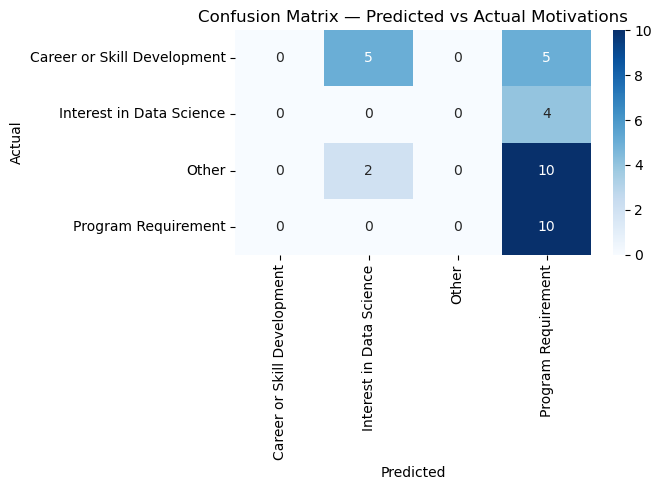

In [56]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Identify relevant columns
program_col = [col for col in combined_df.columns if 'program' in col.lower() or 'programme' in col.lower()]
motivation_col = [col for col in combined_df.columns if 'why' in col.lower() or 'course' in col.lower()]

# Just pick the first matching columns
program_col = program_col[0]
motivation_col = motivation_col[0]
print(f"Using columns:\nProgram: {program_col}\nMotivation: {motivation_col}\n")

# Drop missing values
combined_df = combined_df.dropna(subset=[program_col, motivation_col])

# Clean text
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

# Clean program and motivation text
combined_df['clean_program'] = combined_df[program_col].apply(clean_text)
combined_df['clean_motivation'] = combined_df[motivation_col].apply(clean_text)

# Simplify motivation categories using keyword grouping
def categorize_motivation(text):
    if any(word in text for word in ['interest', 'curious', 'fun', 'enjoy', 'exiting', 'attractive']):
        return 'Interest in Data Science'
    elif any(word in text for word in ['mandatory', 'required', 'compulsory']):
        return 'Program Requirement'
    elif any(word in text for word in ['career', 'future', 'job', 'skill']):
        return 'Career or Skill Development'
    elif any(word in text for word in ['research', 'project', 'thesis', 'commercially', 'useful']):
        return 'Research Relevance'
    else:
        return 'Other'

# Apply categorization
combined_df['motivation_category'] = combined_df['clean_motivation'].apply(categorize_motivation)

# Encode features
X = combined_df['clean_program']
y = combined_df['motivation_category']

# Vectorize program text
vectorizer = TfidfVectorizer(max_features=1000)
X_vec = vectorizer.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42, stratify=y)

# Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix — Predicted vs Actual Motivations')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("/figures/confusion_matrix.pgf")
plt.show()


#### 4. How many people of each study program answered the "Seattle" question correctly?

Number of people in each study program who answered 'Seattle' correctly:

             Which program are you studying  Correct answers
                         MSc Digital Design                1
MSc Digitial Innovation and Management, ITU                6
                              MSc Elsewhere               15
                              MSc Games ITU                1
                   MSc Software Design, ITU               76
                              MSc elsewhere               10


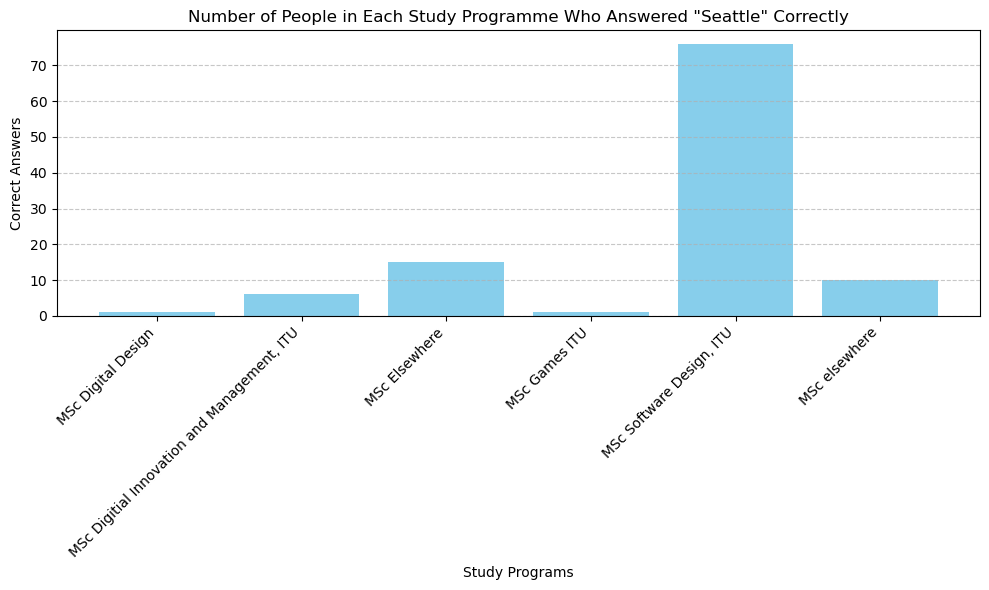

In [58]:

# Replace these with your exact column names if different
answer_col = "How many letters are there in the word Seattle"
program_col = "Which program are you studying"

# Group by study programme and count correct answers
    # Count how many people in each programme answered 'Seattle' correctly (i.e., value == 1)
correct_counts = combined_df[combined_df[answer_col] == 1].groupby(program_col)[answer_col].count().reset_index()

    # Rename columns for readability
correct_counts.columns = [program_col, "Correct answers"]

# Display summary in text
print("Number of people in each study program who answered 'Seattle' correctly:\n")
print(correct_counts.to_string(index=False))

# Plot the results
plt.figure(figsize=(10,6))
plt.bar(correct_counts[program_col], correct_counts["Correct answers"], color='skyblue')
plt.title('Number of People in Each Study Programme Who Answered "Seattle" Correctly')
plt.xlabel('Study Programs')
plt.ylabel('Correct Answers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/figures/correct_answers.pgf")
plt.show()